In [1]:
import numpy as np
import optuna
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import StratifiedShuffleSplit

c:\Users\pablo\Documents\Desarrollo\Trabajo Redes neuronales\entorno_pablo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga de datos de entrenamiento, división para obtener algunos de test y ampliación con transformaciones
En esta versión, **primero** se reconstruye cada imagen a tamaño **80x70**, **después** se aplican las transformaciones y **al final** se aplana para entrenar la red fully connected.


In [2]:
x_path = "X_train.npz"
y_path = "Y_train.npz"

def cargar_npz(ruta):
    data = np.load(ruta)
    
    # Si es un .npz, sacamos el primer array que contenga
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        array = data[data.files[0]]
    else:
        array = data
    
    return array

try:
    X = cargar_npz(x_path)
    Y = cargar_npz(y_path)
except FileNotFoundError:
    raise ValueError("No se encuentran X_train.npz o Y_train.npz dentro de la carpeta datasets")
except Exception as e:
    raise ValueError(f"Error al cargar los datos: {e}")

print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (240, 5600)
Shape de Y: (240,)


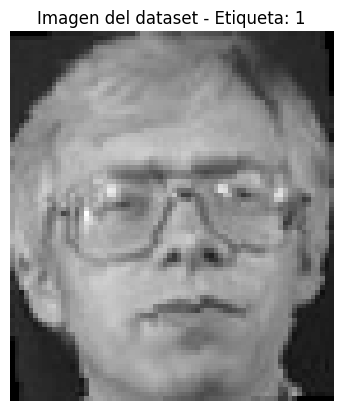

In [14]:
def reconstruir_imagen(img):
    return img.reshape(80, 70)

# Creamos un dataset
dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.long))

img, label = dataset[20]
img_2d = reconstruir_imagen(img)
plt.imshow(img_2d, cmap="gray")
plt.title(f"Imagen del dataset - Etiqueta: {label.item()}")
plt.axis("off")
plt.show()


def make_split(X, Y):
    """5 imágenes por clase en train, 1 en test — estratificado."""
    stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
    train_idx, test_idx = next(stratified_split.split(X, Y))
    print(f'train idx {train_idx}; test_idx: {test_idx} ')

    X_train, Y_train = X[train_idx], Y[train_idx]
    X_test,  Y_test  = X[test_idx],  Y[test_idx]

    print(f"Train: {len(X_train)} imágenes | Test: {len(X_test)} imágenes")
    return (
        TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long)),
        TensorDataset(torch.tensor(X_test,  dtype=torch.float32), torch.tensor(Y_test,  dtype=torch.long)),
    )

In [ ]:
def transform_dataset(dataset):
    transform1 = transforms.Compose([
        transforms.RandomRotation(degrees=15)
    ])
    transform2 = transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0)
    ])
    transform3 = transforms.Compose([
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5)
    ])
    transform4 = transforms.Compose([
        transforms.RandomPerspective(distortion_scale=0.15, p=0.25)
    ])
    transform5 = transforms.Compose([
        transforms.RandomErasing(p=0.35, scale=(0.02, 0.15), ratio=(0.3, 3.0), value='random')
    ])
    
    images = []
    labels = []

    for img, label in dataset:
        img = img.reshape(1, 80, 70)

        aug_imgs = [
            img,
            transform1(img),
            transform2(img),
            transform3(img),
            transform4(img),
            transform5(img)
        ]

        for im in aug_imgs:
            images.append(im)
            labels.append(label)

    X_aug = torch.stack(images)
    Y_aug = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(X_aug, Y_aug)


In [6]:
dataset_train, test_dataset = make_split(X, Y)
train_dataset = transform_dataset(dataset_train)

N_training = len(train_dataset)
N_test = len(test_dataset)

print(f"Dataset de entrenamiento aumentado: {N_training} imágenes")
print(f"Dataset de test sin aumento: {N_test} imágenes")

Train: 200 imágenes | Test: 40 imágenes
Dataset de entrenamiento aumentado: 1200 imágenes
Dataset de test sin aumento: 40 imágenes


## Visualización de algunas imágenes tras las transformaciones
Ejecuta esta celda para comparar imágenes del conjunto de entrenamiento **ya reconstruidas a 80x70** con sus versiones rotadas y espejadas.


Definimos la funcion metric para medir el rendimiento de nuestro modelo

In [ ]:

class ResNet4(nn.Module): 
    def __init__(self, 
            dim_out,
            activation, 
            apply_bn,
            drop_prob,
            link_function, 
            loss_function
        ):
        super(ResNet4, self).__init__()
        
        self.activation = activation
        self.apply_bn = apply_bn
        self.drop = nn.Dropout2d(drop_prob)
        self.link = link_function
        self.loss = loss_function

        ## ===================== ##
        # Capa de Entrada (1 Canal -> 64 Canales)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        ## ===================== ##
        # RESNET BLOCK 1 (64 -> 64)
        self.b1_conv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b1_bn1 = nn.BatchNorm2d(64)
        self.b1_conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b1_bn2 = nn.BatchNorm2d(64)

        ## ===================== ##
        # RESNET BLOCK 2 (64 -> 128)
        self.b2_conv1 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False)
        self.b2_bn1 = nn.BatchNorm2d(128)
        self.b2_conv2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b2_bn2 = nn.BatchNorm2d(128)
        
        self.b2_shortcut_conv = nn.Conv2d(64, 128, kernel_size=1, stride=2, padding=0, bias=False)
        self.b2_shortcut_bn = nn.BatchNorm2d(128)

        ## ===================== ##
        # RESNET BLOCK 3 (128 -> 128)
        self.b3_conv1 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b3_bn1 = nn.BatchNorm2d(128)
        self.b3_conv2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b3_bn2 = nn.BatchNorm2d(128)

        ## ===================== ##
        # RESNET BLOCK 4 (128 -> 256)
        self.b4_conv1 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False)
        self.b4_bn1 = nn.BatchNorm2d(256)
        self.b4_conv2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.b4_bn2 = nn.BatchNorm2d(256)
        
        self.b4_shortcut_conv = nn.Conv2d(128, 256, kernel_size=1, stride=2, padding=0, bias=False)
        self.b4_shortcut_bn = nn.BatchNorm2d(256)
        
        ## ===================== ##
        self.average_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, dim_out)

    def operator(self, x):
        # Reconstruir la imagen 2D si viene aplanada
        if x.dim() == 2 and x.size(1) == 5600:
            x = x.view(-1, 1, 80, 70)

        feature_maps = {}

        x = self.conv1(x)
        if self.apply_bn:
            x = self.bn1(x)
        x = self.activation(x)
        feature_maps['layer1'] = x.clone()

        ## Bloque 1
        x_block = self.b1_conv1(x)
        if self.apply_bn: x_block = self.b1_bn1(x_block)
        x_block = self.b1_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b1_bn2(x_block)
        x = self.drop(self.activation(x + x_block))
        feature_maps['layer2'] = x.clone()

        ## Bloque 2
        x_block = self.b2_conv1(x)
        if self.apply_bn: x_block = self.b2_bn1(x_block)
        x_block = self.b2_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b2_bn2(x_block)
        input_readapted = self.b2_shortcut_conv(x)
        if self.apply_bn: input_readapted = self.b2_shortcut_bn(input_readapted) 
        x = self.drop(self.activation(input_readapted + x_block)) 
        feature_maps['layer3'] = x.clone()

        ## Bloque 3
        x_block = self.b3_conv1(x)
        if self.apply_bn: x_block = self.b3_bn1(x_block)
        x_block = self.b3_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b3_bn2(x_block)
        x = self.drop(self.activation(x + x_block))
        feature_maps['layer4'] = x.clone()

        ## Bloque 4
        x_block = self.b4_conv1(x)
        if self.apply_bn: x_block = self.b4_bn1(x_block)
        x_block = self.b4_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn: x_block = self.b4_bn2(x_block)
        input_readapted = self.b4_shortcut_conv(x)
        if self.apply_bn: input_readapted = self.b4_shortcut_bn(input_readapted) 
        x = self.drop(self.activation(input_readapted + x_block)) 
        feature_maps['layer5'] = x.clone()

        x = self.average_pooling(x)
        feature_maps['layer_pooling'] = x.clone()
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

    def forward_train(self, x, apply_link=False):
        self.train()
        x = self.operator(x)
        if apply_link: x = self.link(x)
        return x

    def forward_eval(self, x, apply_link=True): 
        self.eval()
        x = self.operator(x)
        if apply_link: x = self.link(x)
        return x

    def forward(self, x):
        return self.operator(x)

    def compute_loss(self, t, y):
        return self.loss(y, t)

In [9]:
def compute_metric(dataloader, model):
    acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            acc += (t == torch.argmax(y, dim=1)).sum().item()
            tot_samples += len(t)

    return acc / tot_samples


def compute_metric_global(dataloader, model, k=3):
    acc = compute_metric(dataloader, model)

    top_k_acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            top_k_preds = torch.topk(y, k=k, dim=1).indices
            top_k_acc += top_k_preds.eq(t.view(-1, 1)).any(dim=1).sum().item()
            tot_samples += len(t)

    top_k_acc = top_k_acc / tot_samples
    global_metric = 0.7 * acc + 0.3 * top_k_acc

    return acc, top_k_acc, global_metric

**DEFINICION DEL MODELO**

In [ ]:
def test_model(
    model : torch.nn.Module,
    epochs : int,
    train_batch_size : int,
    lr : float,
    patience : int,
    betas : tuple,
    eps : float,
    weight_decay : float,
    apply_scheduler : bool,
    eval_each : int,
    train_dataset,
    test_dataset
):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_eval = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

    N_training = len(train_dataset)

    loss_epochs = []
    train_global_epochs = []
    test_global_epochs = []

    with torch.no_grad():
        loss_acc = 0.0
        for batch_idx, (x, t) in enumerate(train_loader_eval):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

        _,_,train_global = compute_metric_global(train_loader_eval, model, k=3)
        _,_,test_global = compute_metric_global(test_loader, model, k=3)

    loss_epochs.append(loss_acc / N_training)
    train_global_epochs.append(train_global)
    test_global_epochs.append(test_global)

    best_metric = test_global
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())
#---------------------------------------------------------------
    # OPTIMIZADOR: ADAM
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        betas=betas,
        eps=eps,
        weight_decay=weight_decay
    )

    # SCHEDULER: ReduceLROnPlateau
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=patience,
        min_lr=1e-6
    )
#-------------------------------------------------------------------

    for e in range(epochs):
        model.train()
        loss_acc = 0.0

        for batch_idx, (x, t) in enumerate(train_loader):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

            L.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f"On epoch {e+1} batch_idx {batch_idx + 1} got loss {L.item():.5f}", end="\r")

        if (e + 1) % eval_each == 0 or e == 0:
            with torch.no_grad():
                train_acc, train_top3, train_global = compute_metric_global(train_loader_eval, model, k=3)
                test_acc, test_top3, test_global = compute_metric_global(test_loader, model, k=3)

            if apply_scheduler:
                scheduler.step(test_global)

            if test_global > best_metric:
                best_metric = test_global
                best_epoch = e + 1
                best_state_dict = copy.deepcopy(model.state_dict())

            print(" " * 300, end="\r")
            print(
                f"On epoch {e+1} got loss {loss_acc/N_training:.5f} "
                f"with train accuracy {train_acc:.5f}, train top3 {train_top3:.5f}, train global {train_global:.5f} "
                f"and test accuracy {test_acc:.5f}, test top3 {test_top3:.5f}, test global {test_global:.5f}"
            )
        else:
            print(" " * 300, end="\r")
            print(f"On epoch {e+1} got loss {loss_acc/N_training:.5f}")

        loss_epochs.append(loss_acc / N_training)
        train_global_epochs.append(train_global)
        test_global_epochs.append(test_global)

    model.load_state_dict(best_state_dict)

    print(f"\nEntrenamiento finalizado. Mejor época: {best_epoch} | test_global: {best_metric:.5f}")

    return loss_epochs, train_global_epochs, test_global_epochs

**MODELO OPTIMIZADO DE ADAM (100%)**

In [ ]:
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ResNet4(
    dim_out=40,
    activation=torch.relu,
    apply_bn=True,
    drop_prob=0.22,
    link_function=nn.Softmax(dim=1),
    loss_function=nn.CrossEntropyLoss()
).to(device)

loss_epochs, train_global_epochs, test_global_epochs = test_model(
    model=model,
    epochs=120,
    train_batch_size=8,
    lr=0.0007,
    patience=10,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1.2e-4,
    apply_scheduler=True,
    eval_each=1,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)

On epoch 1 got loss 3.55035 with train accuracy 0.12250, train top3 0.31250, train global 0.17950 and test accuracy 0.10000, test top3 0.32500, test global 0.16750                                                                                                                                         
On epoch 2 got loss 3.13590 with train accuracy 0.23000, train top3 0.48750, train global 0.30725 and test accuracy 0.22500, test top3 0.50000, test global 0.30750                                                                                                                                         
On epoch 3 got loss 2.88091 with train accuracy 0.33917, train top3 0.56833, train global 0.40792 and test accuracy 0.25000, test top3 0.55000, test global 0.34000                                                                                                                                         
On epoch 4 got loss 2.69402 with train accuracy 0.29917, train top3 0.59750, train global 0.38867

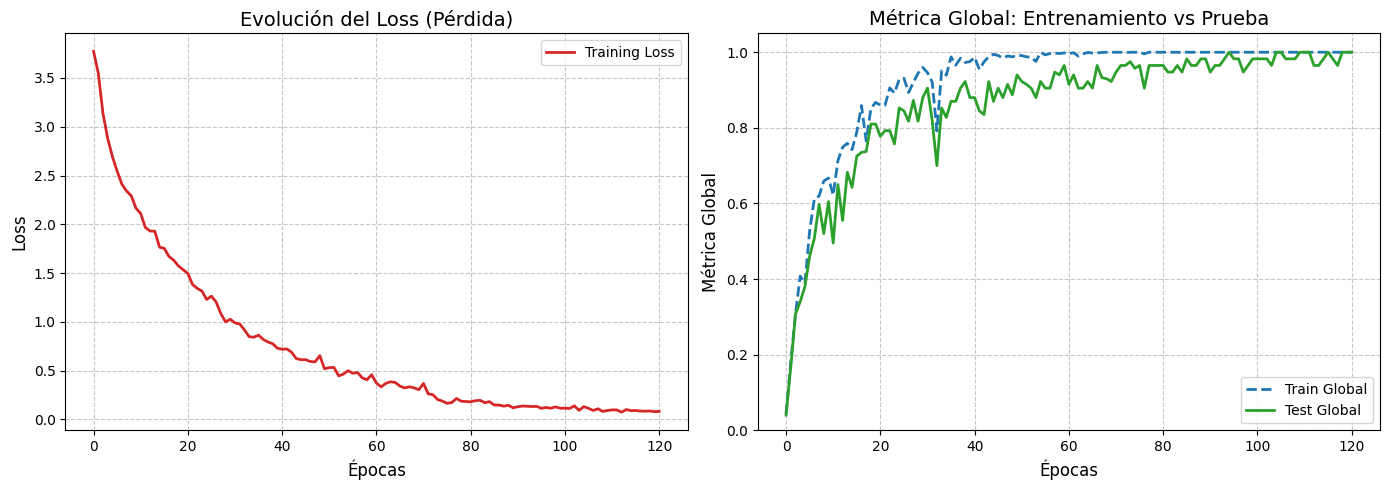

In [17]:

# Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# Gráfico 1: Evolución de la Pérdida (Loss)
# ==========================================
ax1.plot(loss_epochs, label='Training Loss', color='tab:red', linewidth=2)
ax1.set_title('Evolución del Loss (Pérdida)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# ==========================================
# Gráfico 2: Métrica Global (Train vs Test)
# ==========================================
ax2.plot(train_global_epochs, label='Train Global', color='tab:blue', linestyle='--', linewidth=2)
ax2.plot(test_global_epochs, label='Test Global', color='tab:green', linestyle='-', linewidth=2)
ax2.set_title('Métrica Global: Entrenamiento vs Prueba', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Métrica Global', fontsize=12)
ax2.set_ylim([0.0, 1.05]) # La métrica suele ir de 0 a 1
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Ajustar el espaciado y mostrar la gráfica
plt.tight_layout()
plt.show()